# SQL-Gen Analysis — Workload Diversity Evaluation

Coherent, paper-facing evaluation of the query generator against hand-crafted and
generated baselines on TPC-DS. Layout mirrors the paper:

| Section | Table / figure | What it answers |
|---|---|---|
| 0 · Load | — | workloads, universes, styler |
| 1 · Structural diversity | **Table 1** | Are the physical plans distinct, broad, and spread out? |
| 2 · Schema diversity | **Table 2** | Do we touch the whole schema? |
| 3 · Quality & overhead | **Table 3** | Valid, and at what cost? |
| 4 · Analysis: exploration & evenness | figures | Where feedback helps; why raw evenness misranks |

**Headline metric: plan-graph Vendi** (effective number of distinct plans). The
structural table is the thesis; entropy/evenness lives in §4 as *analysis*, not a
scoreboard (it rewards narrowness — see the SQLBarber exhibit).

## 0 · Load workloads, universes, styler

In [1]:
import json, glob, math
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REF       = "tpcds"                              
OURS      = ["gpt_generated_1000_tpcds_tokens"]     
BASELINES = ["bootstrapping_lcm_1000_tokens_tpcds",  # alphabetical by display name
"e2etune_1000_tokens_tpcds",
"sql_factory_1000_tokens_tpcds",
"sqlbarber_1000_tokens_tpcds",
"sqlstorm_1000_tokens_tpcds",
]


plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

# --- load every results CSV; newer file wins on duplicate workload names ------
_files = sorted(glob.glob("results/*.csv"), key=lambda p: Path(p).stat().st_mtime)
df = (pd.concat([pd.read_csv(p) for p in _files], ignore_index=True)
        .drop_duplicates("workload", keep="last").set_index("workload"))


ROWS = [REF] + BASELINES + OURS   # reference first, baselines (A-Z), ours last
missing = [w for w in ROWS if w not in df.index]
assert not missing, f"missing workloads: {missing}"

# --- fixed universes (same denominator for every workload) -------------------
_ops = pd.read_csv(Path("../resources/operators_ground_truth.csv"))
U_OP = int((_ops["category"].astype(str).str.lower() != "dml").sum())   # non-DML operators
print(f"operator universe |U| = {U_OP} (non-DML operators)")

WORKLOAD_ROOTS = [Path("../../Workloads"), Path("/mnt/primary/Main/Workloads")]
def find_report(w):
    for r in WORKLOAD_ROOTS:
        p = Path(r) / w / "generation_report.json"
        if p.exists():
            return json.loads(p.read_text(encoding="utf-8"))
    return None
reports = {w: r for w in ROWS if (r := find_report(w)) is not None}

# --- pretty names + colours + styler -----------------------------------------
PRETTY = {"tpcds":"TPC-DS (ref)", "gpt_generated_1000_tpcds_tokens":"\sys~(Ours)",
          "sqlstorm_1000_tokens_tpcds":"SQLStorm", "sqlbarber_1000_tokens_tpcds":"SQLBarber",
          "sql_factory_1000_tokens_tpcds":"SQL-Factory", "e2etune_1000_tokens_tpcds":"E2ETune",
          "bootstrapping_lcm_1000_tokens_tpcds":"Bootstrapping-LCM"}

COL = {w: "#b8b8b8" for w in ROWS}
for w in OURS: COL[w] = "#ea580c"
COL[REF] = "#111111"
_INV = {v:k for k,v in PRETTY.items()}

def show(tbl, fmt="{:.3f}", **kw):
    disp = tbl.rename(index=PRETTY)
    def hl(row):
        key = _INV.get(row.name, row.name)
        if key == REF:  return ["background-color:#f3f4f6;font-style:italic"]*len(row)
        if key in OURS: return ["background-color:#fff1e6;font-weight:600"]*len(row)
        return [""]*len(row)
    sty = disp.style.apply(hl, axis=1)
    return sty.format(fmt, **kw) if fmt else sty


operator universe |U| = 57 (non-DML operators)


## 1 · Structural diversity  —  **Table 1**

Distinctness, breadth and spread of the compiled physical plans. **Plan-graph
Vendi** (rightmost) is the headline: the effective number of structurally distinct
plans. The others corroborate it — *operator coverage* (breadth of the operator
space), *unique plan-graph ratio* (share of non-duplicate plans), and *mean NN
distance* (spread, so a high Vendi can't be a few outliers).

In [2]:
table1 = pd.DataFrame({
    "Operator types":          df.loc[ROWS, "n_operator_types_observed"],
    "Operator cov. (K/|U|)":   df.loc[ROWS, "n_operator_types_observed"] / U_OP,
    "Unique plan-graph ratio": df.loc[ROWS, "plan_graph_uniqueness_ratio"],
    "Mean NN distance":        df.loc[ROWS, "mean_nearest_neighbour_distance"],
    "Plan-graph Vendi":        df.loc[ROWS, "plan_graph_vendi_score"],
}, index=ROWS).astype(float)

show(table1, None).format({
    "Operator types": "{:.0f}", "Operator cov. (K/|U|)": "{:.2f}",
    "Unique plan-graph ratio": "{:.3f}", "Mean NN distance": "{:.3f}",
    "Plan-graph Vendi": "{:.1f}",
})

,Operator types,Operator cov. (K/|U|),Unique plan-graph ratio,Mean NN distance,Plan-graph Vendi
TPC-DS (ref),29,0.51,0.848,0.243,22.3
Bootstrapping-LCM,28,0.49,0.916,0.138,19.0
E2ETune,30,0.53,0.976,0.245,55.3
SQL-Factory,30,0.53,0.965,0.219,52.4
SQLBarber,26,0.46,0.108,0.002,16.4
SQLStorm,35,0.61,0.790,0.270,77.6
\sys~(Ours),37,0.65,1.000,0.374,106.1


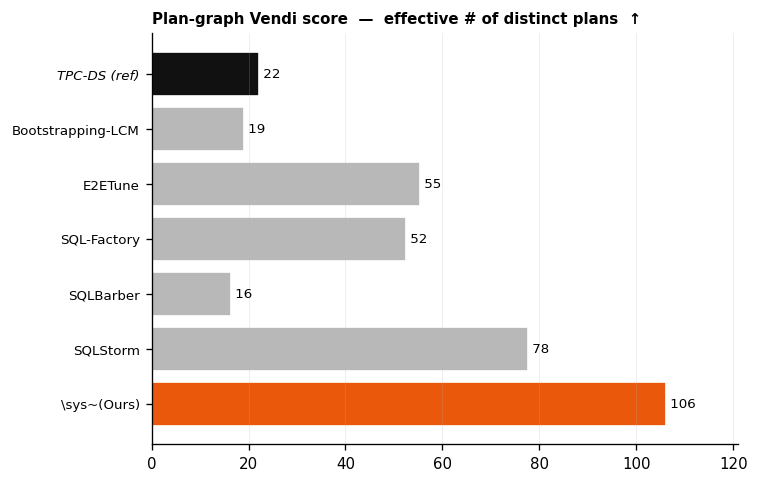

In [3]:
# headline figure: plan-graph Vendi
fig, ax = plt.subplots(figsize=(6.4, 0.5*len(ROWS)+0.6))
vals = table1["Plan-graph Vendi"]
ax.barh(range(len(ROWS)), vals.values, color=[COL[w] for w in ROWS], edgecolor="white")
for i, v in enumerate(vals.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels([PRETTY[w] for w in ROWS], fontsize=8)
ax.get_yticklabels()[0].set_fontstyle("italic")
ax.invert_yaxis(); ax.margins(x=0.14); ax.grid(axis="y", visible=False)
ax.set_title("Plan-graph Vendi score  —  effective # of distinct plans  ↑",
             loc="left", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

## 2 · Schema diversity  —  **Table 2**

Do the queries touch the whole schema, and are table combinations varied?
*Coverage* is the fraction of tables / columns / FK-edges referenced anywhere;
*unique table-set ratio* is the share of distinct table combinations. All in
`[0,1]`, higher is better. (Usage **entropy** is deferred to §4.)

In [4]:
table2 = pd.DataFrame({
    "Table cov.":              df.loc[ROWS, "table_coverage"],
    "Column cov.":             df.loc[ROWS, "column_coverage"],
    "Join-edge cov.":          df.loc[ROWS, "join_edge_coverage"],
    "Unique table-set ratio":  df.loc[ROWS, "unique_table_set_ratio"],
}, index=ROWS).astype(float)

show(table2)

,Table cov.,Column cov.,Join-edge cov.,Unique table-set ratio
TPC-DS (ref),1.000,0.581,0.683,0.657
Bootstrapping-LCM,1.000,0.800,1.000,0.394
E2ETune,1.000,0.904,1.000,0.882
SQL-Factory,1.000,0.805,0.988,0.382
SQLBarber,1.000,0.593,0.963,0.122
SQLStorm,1.000,0.744,0.768,0.397
\sys~(Ours),1.000,0.979,1.000,0.932


## 3 · Quality & overhead  —  **Table 3**

*Validity* = queries that parse **and** execute / queries requested (baselines are
distributed pre-validated, so they read ~100%). Overhead (wall-clock, throughput)
is only defined for generators we ran end-to-end; external baselines show —.

In [5]:
def _get(w, col):
    # tolerant: missing column (older CSVs) or missing value -> NaN, never an error
    v = df.loc[w].get(col, np.nan) if col in df.columns else np.nan
    return float(v) if pd.notna(v) else np.nan

table3 = pd.DataFrame({
    "Validity %":      df.loc[ROWS, "ok"] / df.loc[ROWS, "query_count"] * 100,
    "Gen. time (min)": [ _get(w, "gen_duration_s")/60.0 for w in ROWS ],
    "Queries / min":   [ _get(w, "gen_queries_per_min") for w in ROWS ],
    "Sec / query":     [ _get(w, "gen_seconds_per_query") for w in ROWS ],
    "Tokens / query":  [ _get(w, "gen_tokens_per_query") for w in ROWS ],   # blank for pre-token CSVs
    "Reject rate":     [ _get(w, "gen_rejection_rate") for w in ROWS ],
}, index=ROWS)

show(table3, None).format({
    "Validity %": "{:.1f}", "Gen. time (min)": "{:.1f}", "Queries / min": "{:.2f}",
    "Sec / query": "{:.1f}", "Tokens / query": "{:,.0f}", "Reject rate": "{:.1%}",
}, na_rep="—")

,Validity %,Gen. time (min),Queries / min,Sec / query,Tokens / query,Reject rate
TPC-DS (ref),100.0,—,—,—,—,—
Bootstrapping-LCM,100.0,456.0,2.19,27.4,"12,734",—
E2ETune,100.0,239.5,4.17,14.4,"7,985",—
SQL-Factory,100.0,332.0,3.01,19.9,"3,198",—
SQLBarber,100.0,193.8,5.16,11.6,"1,072",—
SQLStorm,100.0,899.9,1.11,54.0,"26,329",—
\sys~(Ours),100.0,130.7,7.65,7.8,"14,876",51.2%


## 4 · Analysis: exploration & the evenness artifact

This section is the paper's *characterisation*, not a scoreboard. Two linked points.

### 4a · Why we don't report operator/n-gram **entropy** as a headline
The usual metric is Pielou **evenness** `H / ln(K_obs)`, normalised by the number
of distinct elements *that workload happened to touch*. That denominator rewards
**narrowness**: a generator that discovers more operator types is divided by a
larger `ln K`, so it scores lower evenness even at equal raw entropy. The exhibit
below: **SQLBarber tops operator evenness while being the least diverse workload by
every count metric** (plan-uniqueness 0.12, mean-NN 0.001, Vendi 19). A metric that
crowns near-duplicates as "most uniform" is measuring the wrong thing.

We instead read two fair quantities: the **effective number** `N1 = exp(H) =
K^evenness` (universe-free, the same "effective number" idea as Vendi) and
**fixed-universe evenness** `E* = H / ln|U|` (shared denominator). On these we are
on par with the strongest baselines while covering strictly more of the space — so
the apparent operator-entropy "gap" is a normalisation artifact.

In [6]:
def fixed_evenness(ev, k, U):
    return (ev*math.log(k))/math.log(U) if (k and k>1 and U>1) else np.nan
def effective_number(ev, k):
    return math.exp(ev*math.log(k)) if (k and k>1) else np.nan

_K  = df.loc[ROWS, "n_operator_types_observed"].astype(float)
_EV = df.loc[ROWS, "operator_type_entropy"].astype(float)
evenness = pd.DataFrame({
    "Operator types (K)":    _K,
    "Evenness (obs, H/lnK)": _EV,                                    # the misleading metric
    "Effective # (N1)":      [effective_number(e,k) for e,k in zip(_EV,_K)],
    "Evenness (fixed |U|)":  [fixed_evenness(e,k,U_OP) for e,k in zip(_EV,_K)],
}, index=ROWS)
show(evenness, None).format({
    "Operator types (K)":"{:.0f}", "Evenness (obs, H/lnK)":"{:.3f}",
    "Effective # (N1)":"{:.2f}", "Evenness (fixed |U|)":"{:.3f}",
})

,Operator types (K),"Evenness (obs, H/lnK)",Effective # (N1),Evenness (fixed |U|)
TPC-DS (ref),29,0.680,9.88,0.567
Bootstrapping-LCM,28,0.676,9.51,0.557
E2ETune,30,0.723,11.71,0.609
SQL-Factory,30,0.736,12.24,0.620
SQLBarber,26,0.725,10.62,0.584
SQLStorm,35,0.692,11.73,0.609
\sys~(Ours),37,0.658,10.75,0.587


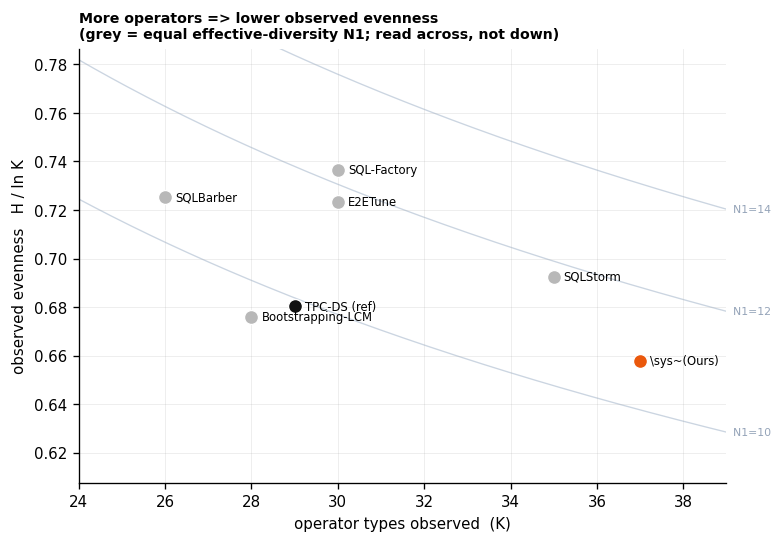

In [64]:
# the artifact, visualised: along a constant effective-diversity (N1) curve,
# evenness MUST fall as K rises  ->  broad generators are pushed down the axis.
# Zoomed to the observed K range (+ padding), not all the way to |U|, since with
# this few points the long unused tail just compresses everything into a corner.
_K_obs = df.loc[ROWS, "n_operator_types_observed"].astype(float)
_EV_obs = df.loc[ROWS, "operator_type_entropy"].astype(float)
_k_lo, _k_hi = _K_obs.min() - 2, _K_obs.max() + 2
_ev_lo, _ev_hi = _EV_obs.min() - 0.05, _EV_obs.max() + 0.05

fig, ax = plt.subplots(figsize=(6.6, 4.6))
_k = np.linspace(_k_lo, _k_hi, 200)
for n1 in [10, 12, 14]:
    ax.plot(_k, np.log(n1)/np.log(_k), color="#cbd5e1", lw=0.8, zorder=1)
    ax.text(_k_hi, np.log(n1)/np.log(_k_hi), f"  N1={n1}", fontsize=6.5, color="#94a3b8", va="center")
for w in ROWS:
    k, e = float(df.loc[w,"n_operator_types_observed"]), float(df.loc[w,"operator_type_entropy"])
    ax.scatter(k, e, color=COL[w], s=70, edgecolor="white", lw=0.8, zorder=3)
    ax.annotate(PRETTY[w], (k,e), fontsize=7, xytext=(6,0), textcoords="offset points", va="center")
ax.set_xlim(_k_lo, _k_hi)  # extra headroom on the right for the N1 labels
ax.set_ylim(_ev_lo, _ev_hi)  # extra headroom on the top for the N1 labels  
ax.set_xlabel("operator types observed  (K)"); ax.set_ylabel("observed evenness   H / ln K")
ax.set_title("More operators => lower observed evenness\n(grey = equal effective-diversity N1; read across, not down)",
             loc="left", fontsize=8.5, fontweight="bold")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

### 4b · Exploration dynamics: where coverage feedback helps

Sub-hypothesis: coverage feedback raises diversity **only while the operator
vocabulary is unsaturated**; once the ceiling is hit, selection-side steering
converges to the no-feedback baseline and further gains need generation-side
levers. Evidence below is the **discovery rate** (new operators per accepted query)
early vs late in each of our runs — a sharp early-to-late drop is the saturation
signature. *(The formal feedback-on vs feedback-off ablation is the one run still
pending; drop it in here when ready.)*

In [8]:
rows = []
for w, rep in reports.items():
    pf = rep.get("plan_feedback", {})
    rows.append({
        "workload": PRETTY.get(w, w),
        "operators covered": pf.get("operators_covered"),
        "reachable": pf.get("operators_reachable"),
        "discovery rate (first 100)": pf.get("discovery_rate_first100"),
        "discovery rate (last 100)":  pf.get("discovery_rate_last100"),
    })
disc = pd.DataFrame(rows).set_index("workload")
disc if len(disc) else print("no plan_feedback in loaded reports")

,operators covered,reachable,discovery rate (first 100),discovery rate (last 100)
workload,,,,
Bootstrapping-LCM,NaN,NaN,NaN,NaN
E2ETune,NaN,NaN,NaN,NaN
SQL-Factory,NaN,NaN,NaN,NaN
SQLBarber,NaN,NaN,NaN,NaN
SQLStorm,NaN,NaN,NaN,NaN
\sys~(Ours),12.0,25.0,2.98,0.39


---
**Reported set (nothing else in headline tables).** Table 1: operator types,
operator coverage, unique plan-graph ratio, mean NN distance, plan-graph Vendi.
Table 2: table / column / join-edge coverage, unique table-set ratio. Table 3:
validity %, generation time, throughput. §4 (analysis only): effective number /
fixed-|U| evenness, exploration dynamics.

## 5 · LaTeX export

Generates `booktabs`-style LaTeX for Tables 1–3 (and the §4 evenness table) directly
from the DataFrames built above, so the paper always matches what's on screen. Best
value per column is bolded (excluding the reference row, which is context not a
competitor); `--` marks NaN. Each table is wrapped in `\resizebox{\linewidth}{!}{...}`
so it always fits the column/page width regardless of how many metrics it holds.
Requires `\usepackage{booktabs}` and `\usepackage{graphicx}` in the preamble.

In [9]:
_LATEX_SPECIAL = {"%": r"\%", "&": r"\&", "_": r"\_", "#": r"\#"}
def _tex_escape(s):
    for ch, esc in _LATEX_SPECIAL.items():
        s = s.replace(ch, esc)
    return s

def to_latex(tbl, fmts, caption, label, higher_is_better=True, ref=REF, ours=OURS):
    """Render `tbl` (index = raw workload keys) as a booktabs LaTeX table.

    fmts: {column -> format spec}, e.g. "{:.3f}", "{:.0f}", "{:.1%}".
    higher_is_better: True/False, or a dict per-column, controlling which value
    is bolded (best among non-reference rows; ties all bold, unless *every*
    competitor ties -- then nothing is bolded, since there's no winner to flag).
    Reference row is never bolded. Row order follows `tbl.index` as given
    (reference, then baselines, then ours last). Only the reference block gets
    its own \\midrule; ours sits directly below the baselines with no rule
    between them. Column headers, caption and cell values all get LaTeX special
    characters (%, &, _, #) escaped, so raw names like "Validity %" don't
    silently truncate the row via an unescaped comment character. The tabular
    is wrapped in \\resizebox{\\linewidth}{!}{...} so it always fits the page
    width regardless of column count (requires \\usepackage{graphicx}).
    """
    cols = list(fmts.keys())
    hib = higher_is_better if isinstance(higher_is_better, dict) else {c: higher_is_better for c in cols}

    # best value per column, over non-reference rows only (need >=2 to compare);
    # ties are resolved on the *formatted* string so e.g. 0.9996 and 1.000 that
    # both display as "1.000" both get bolded, not just whichever sorts first.
    # If every competitor ties on that formatted value, there's no winner to
    # highlight, so skip bolding the column entirely.
    competitors = [w for w in tbl.index if w != ref]
    best_disp = {}
    for c in cols:
        vals = tbl.loc[competitors, c].astype(float)
        notna = vals.dropna()
        if len(notna) >= 2:
            best_val = notna.max() if hib.get(c, True) else notna.min()
            disp = fmts[c].format(best_val)
            if any(fmts[c].format(v) != disp for v in notna):
                best_disp[c] = disp

    def fmt_cell(w, c):
        v = tbl.loc[w, c]
        if pd.isna(v):
            return "--"
        s = fmts[c].format(float(v))
        is_best = w != ref and best_disp.get(c) == s
        s = _tex_escape(s)
        if is_best:
            s = r"\textbf{" + s + "}"
        return s

    colspec = "l" + "r" * len(cols)
    body = [
        r"\begin{tabular}{" + colspec + "}",
        r"\toprule",
        "Workload & " + " & ".join(_tex_escape(c) for c in cols) + r" \\",
        r"\midrule",
    ]
    for w in tbl.index:
        name = PRETTY.get(w, w)
        if w == ref:
            name = r"\textit{" + name + "}"
        elif w in ours:
            name = r"\textbf{" + name + "}"
        row = " & ".join(fmt_cell(w, c) for c in cols)
        body.append(f"{name} & {row} " + r"\\")
        if w == ref:
            body.append(r"\midrule")
    body += [r"\bottomrule", r"\end{tabular}"]

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        r"\caption{" + _tex_escape(caption) + "}",
        r"\label{" + label + "}",
        r"\resizebox{\linewidth}{!}{%",
        *body,
        r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


In [10]:
print(to_latex(
    table1,
    {"Operator types": "{:.0f}", "Operator cov. (K/|U|)": "{:.2f}",
     "Unique plan-graph ratio": "{:.3f}", "Mean NN distance": "{:.3f}",
     "Plan-graph Vendi": "{:.1f}"},
    caption="Structural diversity of compiled physical plans on TPC-DS.",
    label="tab:structural-diversity",
))


\begin{table}[t]
\centering
\caption{Structural diversity of compiled physical plans on TPC-DS.}
\label{tab:structural-diversity}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrrr}
\toprule
Workload & Operator types & Operator cov. (K/|U|) & Unique plan-graph ratio & Mean NN distance & Plan-graph Vendi \\
\midrule
\textit{TPC-DS (ref)} & 29 & 0.51 & 0.848 & 0.243 & 22.3 \\
\midrule
Bootstrapping-LCM & 28 & 0.49 & 0.916 & 0.138 & 19.0 \\
E2ETune & 30 & 0.53 & 0.976 & 0.245 & 55.3 \\
SQL-Factory & 30 & 0.53 & 0.965 & 0.219 & 52.4 \\
SQLBarber & 26 & 0.46 & 0.108 & 0.002 & 16.4 \\
SQLStorm & 35 & 0.61 & 0.790 & 0.270 & 77.6 \\
\textbf{\sys~(Ours)} & \textbf{37} & \textbf{0.65} & \textbf{1.000} & \textbf{0.374} & \textbf{106.1} \\
\bottomrule
\end{tabular}
}
\end{table}


In [11]:
print(to_latex(
    table2,
    {"Table cov.": "{:.3f}", "Column cov.": "{:.3f}",
     "Join-edge cov.": "{:.3f}", "Unique table-set ratio": "{:.3f}"},
    caption="Schema diversity: coverage and table-combination breadth on TPC-DS.",
    label="tab:schema-diversity",
))


\begin{table}[t]
\centering
\caption{Schema diversity: coverage and table-combination breadth on TPC-DS.}
\label{tab:schema-diversity}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrr}
\toprule
Workload & Table cov. & Column cov. & Join-edge cov. & Unique table-set ratio \\
\midrule
\textit{TPC-DS (ref)} & 1.000 & 0.581 & 0.683 & 0.657 \\
\midrule
Bootstrapping-LCM & 1.000 & 0.800 & \textbf{1.000} & 0.394 \\
E2ETune & 1.000 & 0.904 & \textbf{1.000} & 0.882 \\
SQL-Factory & 1.000 & 0.805 & 0.988 & 0.382 \\
SQLBarber & 1.000 & 0.593 & 0.963 & 0.122 \\
SQLStorm & 1.000 & 0.744 & 0.768 & 0.397 \\
\textbf{\sys~(Ours)} & 1.000 & \textbf{0.979} & \textbf{1.000} & \textbf{0.932} \\
\bottomrule
\end{tabular}
}
\end{table}


In [12]:
print(to_latex(
    table3,
    {"Validity %": "{:.1f}", "Gen. time (min)": "{:.1f}", "Queries / min": "{:.2f}",
     "Sec / query": "{:.1f}", "Tokens / query": "{:,.0f}", "Reject rate": "{:.1%}"},
    caption="Query quality and generation overhead on TPC-DS. Overhead is only "
            "defined for generators run end-to-end; external baselines are "
            "distributed pre-generated.",
    label="tab:quality-overhead",
    higher_is_better={"Validity %": True, "Gen. time (min)": False, "Queries / min": True,
                       "Sec / query": False, "Tokens / query": False, "Reject rate": False},
))


\begin{table}[t]
\centering
\caption{Query quality and generation overhead on TPC-DS. Overhead is only defined for generators run end-to-end; external baselines are distributed pre-generated.}
\label{tab:quality-overhead}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrrrr}
\toprule
Workload & Validity \% & Gen. time (min) & Queries / min & Sec / query & Tokens / query & Reject rate \\
\midrule
\textit{TPC-DS (ref)} & 100.0 & -- & -- & -- & -- & -- \\
\midrule
Bootstrapping-LCM & 100.0 & 456.0 & 2.19 & 27.4 & 12,734 & -- \\
E2ETune & 100.0 & 239.5 & 4.17 & 14.4 & 7,985 & -- \\
SQL-Factory & 100.0 & 332.0 & 3.01 & 19.9 & 3,198 & -- \\
SQLBarber & 100.0 & 193.8 & 5.16 & 11.6 & \textbf{1,072} & -- \\
SQLStorm & 100.0 & 899.9 & 1.11 & 54.0 & 26,329 & -- \\
\textbf{\sys~(Ours)} & 100.0 & \textbf{130.7} & \textbf{7.65} & \textbf{7.8} & 14,876 & 51.2\% \\
\bottomrule
\end{tabular}
}
\end{table}


In [13]:
print(to_latex(
    evenness,
    {"Operator types (K)": "{:.0f}", "Evenness (obs, H/lnK)": "{:.3f}",
     "Effective # (N1)": "{:.2f}", "Evenness (fixed |U|)": "{:.3f}"},
    caption="Operator-usage evenness: raw (narrowness-biased) vs. universe-free "
            "and fixed-$|U|$ alternatives.",
    label="tab:evenness",
))


\begin{table}[t]
\centering
\caption{Operator-usage evenness: raw (narrowness-biased) vs. universe-free and fixed-$|U|$ alternatives.}
\label{tab:evenness}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lrrrr}
\toprule
Workload & Operator types (K) & Evenness (obs, H/lnK) & Effective \# (N1) & Evenness (fixed |U|) \\
\midrule
\textit{TPC-DS (ref)} & 29 & 0.680 & 9.88 & 0.567 \\
\midrule
Bootstrapping-LCM & 28 & 0.676 & 9.51 & 0.557 \\
E2ETune & 30 & 0.723 & 11.71 & 0.609 \\
SQL-Factory & 30 & \textbf{0.736} & \textbf{12.24} & \textbf{0.620} \\
SQLBarber & 26 & 0.725 & 10.62 & 0.584 \\
SQLStorm & 35 & 0.692 & 11.73 & 0.609 \\
\textbf{\sys~(Ours)} & \textbf{37} & 0.658 & 10.75 & 0.587 \\
\bottomrule
\end{tabular}
}
\end{table}
